In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_cluster = pd.read_pickle("tiktok_id_with_embeddings.pkl")

In [3]:
df_cluster.head()

,id,text_embedding,audio_embedding,video_embedding,fused_embedding,cluster,cluster_prob,umap_x,umap_y
0,7503278148864249110,"[-3.794837, 0.63037974, 1.509788, 0.1374473, 1...","[0.3237541, -0.11235112, -0.119736336, -0.2200...","[-0.030400887, 0.020024313, -0.00441134, -0.02...","[-0.024680756, 0.010101808, 0.0012954228, -0.0...",-1,0.000000,4.632422,3.140967
1,7558613478487887159,"[2.0479257, 1.5895466, 2.754304, -5.274406, 0....","[0.0154381795, -0.30264804, -0.035481215, 0.29...","[0.019787952, 0.034039684, 0.0026121866, -0.06...","[0.022484021, 0.019446295, 0.01438221, -0.0536...",5,1.000000,0.358761,3.505548
2,7623749782456028438,"[-1.4934034, 3.337984, -1.4402719, -1.0264286,...","[-0.19018753, -0.383762, -0.36902225, 0.505358...","[0.0012865608, -0.0015610565, 0.009077488, -0....","[-0.012402791, 0.0036785572, -0.01298568, 0.00...",3,0.940509,5.593432,2.040792
3,7623763685936319757,"[-0.79755646, -2.2601898, 1.5637699, -4.866456...","[0.2267509, 0.21168669, -0.09216305, 0.1963428...","[0.027527297, 0.0245002, 0.008045874, -0.03352...","[0.019455487, 0.00997333, 0.009864301, -0.0385...",4,0.884276,4.875210,1.147017
4,7576694388135349526,"[2.055077, 1.7504302, -1.025878, -1.43647, 3.3...","[-0.19136031, -0.11420477, -0.12968163, 0.1321...","[-0.0110944165, 0.011763652, 0.008338223, -0.0...","[-0.0022890368, 0.012174677, -0.004106117, -0....",5,1.000000,1.841355,3.392950


In [5]:
cluster_name = {
    0: "Nostaglic feelings and artifacts",
    1: "Physical media enthusiasm",
    2: "Analog photgraphy",
    3: "Opinions and recs on digital detox",
    4: "Analog experiences in vlog format",
    5: "Being offline as the superior",
    6: "Aesthetic showcase of hobbyist activities"
}

/var/folders/vn/pqv9p4rs4wzbkzsr396jhw_00000gn/T/ipykernel_18497/1692904121.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_labels))


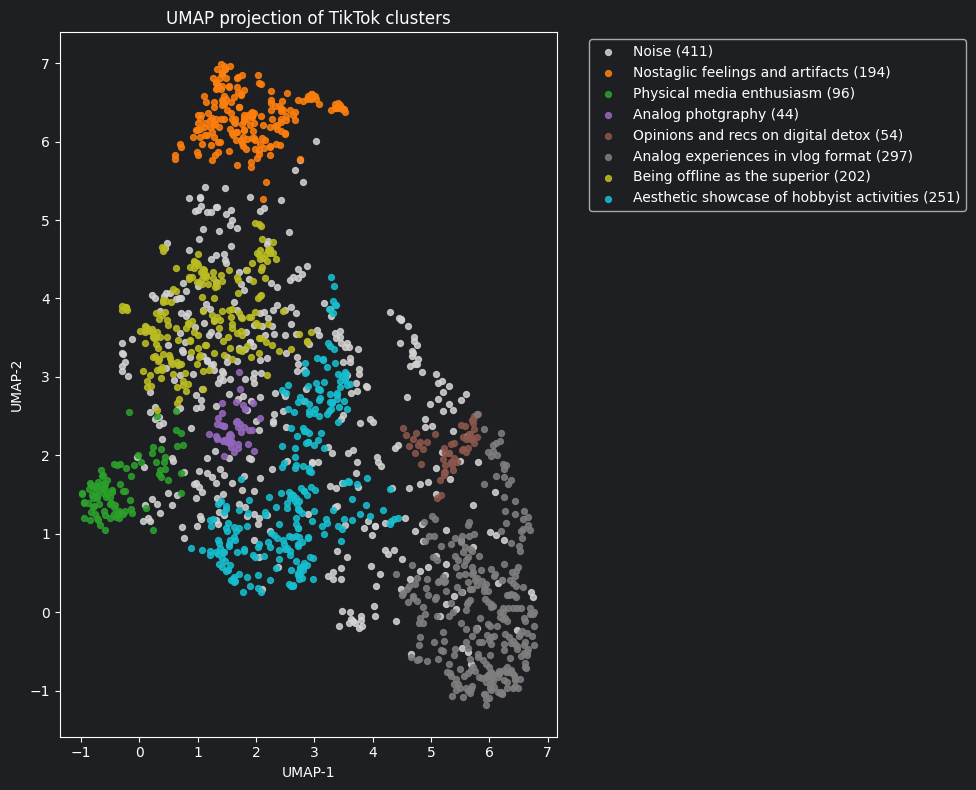

In [7]:
X_2d = df_cluster[["umap_x", "umap_y"]].values
labels = df_cluster["cluster"].values

plt.figure(figsize=(10, 8))

unique_labels = sorted(np.unique(labels))

# get a colormap
cmap = plt.cm.get_cmap("tab10", len(unique_labels))

for i, cluster_id in enumerate(unique_labels):
    mask = labels == cluster_id
    n_points = mask.sum()

    if cluster_id == -1:
        color = "lightgray"
        label_name = f"Noise ({n_points})"
    else:
        color = cmap(i)
        label_name = f"{cluster_name[cluster_id]} ({n_points})"

    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        s=18,
        alpha=0.85,
        color=color,
        label=label_name,
    )

plt.title("UMAP projection of TikTok clusters")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
df_medoid = pd.read_pickle("medoid_neighbors.pkl")